
--- DATASET PREVIEW ---
   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           1

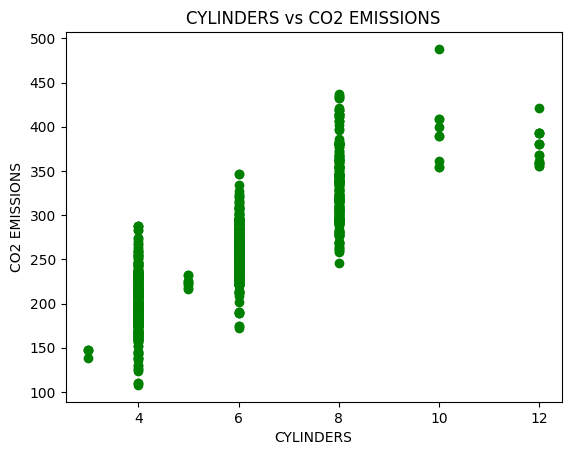


Q2: Scatter plot comparison - CYLINDERS vs CO2EMISSIONS and ENGINESIZE vs CO2EMISSIONS


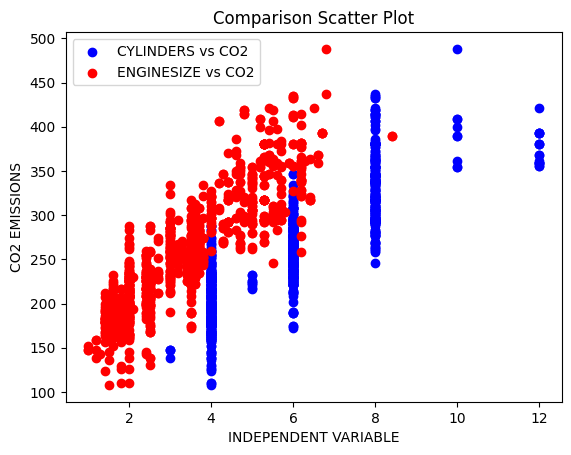


Q3: Scatter plot comparison - CYLINDERS, ENGINESIZE, FUELCONSUMPTION_COMB vs CO2EMISSIONS


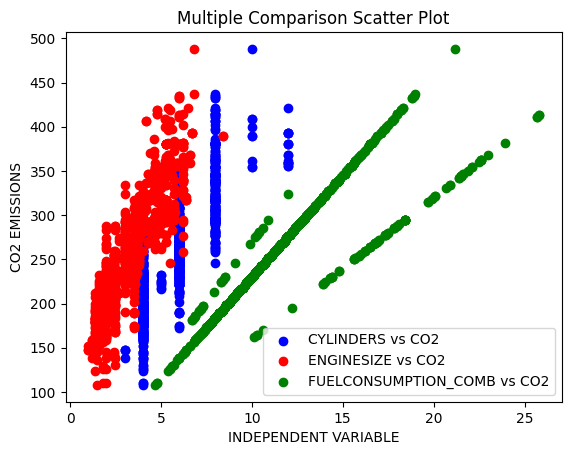


Q4: Linear Regression Model - CYLINDERS vs CO2EMISSIONS
Accuracy (R2 Score): 0.7317140029783895

Q5: Linear Regression Model - FUELCONSUMPTION_COMB vs CO2EMISSIONS
Accuracy (R2 Score): 0.8071474868274242

Q6: Model Accuracy with Different Train-Test Ratios (FUELCONSUMPTION_COMB vs CO2EMISSIONS)
Train-Test Ratio 0.8:0.2 → Accuracy (R2 Score): 0.8071474868274242
Train-Test Ratio 0.7:0.3 → Accuracy (R2 Score): 0.8000872270086814
Train-Test Ratio 0.6:0.4 → Accuracy (R2 Score): 0.8044095877480966


In [3]:
# Program developed by : Your Name
# Register Number      : Your Register No.

# Q0: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset (Upload your CSV in Colab)
# Example file name: FuelConsumption.csv
df = pd.read_csv("FuelConsumption.csv")

# Convert 'Cylinders' to uppercase column name
df.rename(columns={'Cylinders': 'CYLINDERS'}, inplace=True)

# Display first rows
print("\n--- DATASET PREVIEW ---")
print(df.head())

# Q1: Scatter plot CYLINDERS vs CO2EMISSIONS
print("\nQ1: Scatter plot - CYLINDERS vs CO2EMISSIONS")
plt.scatter(df['CYLINDERS'], df['CO2EMISSIONS'], color='green')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2 EMISSIONS")
plt.title("CYLINDERS vs CO2 EMISSIONS")
plt.show()

# Q2: Compare CYLINDERS vs CO2EMISSIONS and ENGINESIZE vs CO2EMISSIONS
print("\nQ2: Scatter plot comparison - CYLINDERS vs CO2EMISSIONS and ENGINESIZE vs CO2EMISSIONS")
plt.scatter(df['CYLINDERS'], df['CO2EMISSIONS'], color='blue', label='CYLINDERS vs CO2')
plt.scatter(df['ENGINESIZE'], df['CO2EMISSIONS'], color='red', label='ENGINESIZE vs CO2')
plt.xlabel("INDEPENDENT VARIABLE")
plt.ylabel("CO2 EMISSIONS")
plt.title("Comparison Scatter Plot")
plt.legend()
plt.show()

# Q3: Compare CYLINDERS, ENGINESIZE, FUELCONSUMPTION_COMB vs CO2EMISSIONS
print("\nQ3: Scatter plot comparison - CYLINDERS, ENGINESIZE, FUELCONSUMPTION_COMB vs CO2EMISSIONS")
plt.scatter(df['CYLINDERS'], df['CO2EMISSIONS'], color='blue', label='CYLINDERS vs CO2')
plt.scatter(df['ENGINESIZE'], df['CO2EMISSIONS'], color='red', label='ENGINESIZE vs CO2')
plt.scatter(df['FUELCONSUMPTION_COMB'], df['CO2EMISSIONS'], color='green', label='FUELCONSUMPTION_COMB vs CO2')
plt.xlabel("INDEPENDENT VARIABLE")
plt.ylabel("CO2 EMISSIONS")
plt.title("Multiple Comparison Scatter Plot")
plt.legend()
plt.show()

# Q4: Train model (CYLINDERS vs CO2 Emission)
print("\nQ4: Linear Regression Model - CYLINDERS vs CO2EMISSIONS")
X_cyl = df[['CYLINDERS']]
y = df['CO2EMISSIONS']
X_train, X_test, y_train, y_test = train_test_split(X_cyl, y, test_size=0.2, random_state=42)

model_cyl = LinearRegression()
model_cyl.fit(X_train, y_train)

y_pred_cyl = model_cyl.predict(X_test)
print("Accuracy (R2 Score):", r2_score(y_test, y_pred_cyl))

# Q5: Train model (FUELCONSUMPTION_COMB vs CO2 Emission)
print("\nQ5: Linear Regression Model - FUELCONSUMPTION_COMB vs CO2EMISSIONS")
X_fuel = df[['FUELCONSUMPTION_COMB']]
X_train, X_test, y_train, y_test = train_test_split(X_fuel, y, test_size=0.2, random_state=42)

model_fuel = LinearRegression()
model_fuel.fit(X_train, y_train)

y_pred_fuel = model_fuel.predict(X_test)
print("Accuracy (R2 Score):", r2_score(y_test, y_pred_fuel))

# Q6: Train with different train-test ratios
print("\nQ6: Model Accuracy with Different Train-Test Ratios (FUELCONSUMPTION_COMB vs CO2EMISSIONS)")
ratios = [0.2, 0.3, 0.4]
for ratio in ratios:
    X_train, X_test, y_train, y_test = train_test_split(df[['FUELCONSUMPTION_COMB']], y, test_size=ratio, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Train-Test Ratio {1-ratio:.1f}:{ratio:.1f} → Accuracy (R2 Score): {r2_score(y_test, y_pred)}")
